# Customer Churn Prediction — Preprocessing, Modeling & Evaluation
**Course Project — BIL 476 Data Mining (Summer 2026)**

This notebook uses the cleaned dataset created by `01_eda_and_cleaning.ipynb`.
It:

1. Splits the raw features into stratified 80/20 train and test sets.
2. Performs one-hot encoding and, for k-NN, standardization inside each
   cross-validation fold.
3. Tunes Decision Tree, Gaussian Naive Bayes, k-NN, and Random Forest models.
4. Compares baseline models with SMOTENC variants fitted only on training folds.
5. Evaluates Accuracy, Precision, Recall, F1, ROC-AUC, and PR-AUC.
6. Saves the final table and report figures to the project folders.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_STATE)


## 1. Load Cleaned Data & Define Feature Types


In [2]:
df = pd.read_csv("../data/telco_clean.csv")

# Keep raw feature types until after the split. This lets preprocessing and
# SMOTENC learn only from the relevant training fold during cross-validation.
y = df["Churn_binary"]
X = df.drop(columns=["Churn", "Churn_binary"])

categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_columns = [column for column in X.columns if column not in categorical_columns]
categorical_indices = [X.columns.get_loc(column) for column in categorical_columns]

print("Raw feature matrix shape:", X.shape)
print("Categorical columns:", len(categorical_columns))
print("Numeric columns:", len(numeric_columns))
X.head()


Raw feature matrix shape: (7043, 19)
Categorical columns: 16
Numeric columns: 3


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


## 2. Train/Test Split (Stratified 80/20)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " | Churn rate:", y_train.mean().round(3))
print("Test shape:", X_test.shape, " | Churn rate:", y_test.mean().round(3))

# Encoding and scaling are deliberately not fitted here. They are pipeline
# steps, so GridSearchCV refits them independently inside every training fold.


Train shape: (5634, 19)  | Churn rate: 0.265
Test shape: (1409, 19)  | Churn rate: 0.265


## 3. Baseline Models with Leakage-Safe Hyperparameter Tuning

Each model is tuned with stratified 5-fold cross-validation, optimizing
F1-score for the churn class. One-hot encoding, and k-NN scaling, are fitted
inside each fold rather than before `GridSearchCV`.


In [4]:
def make_preprocessor(scale_numeric=False):
    numeric_transformer = StandardScaler() if scale_numeric else "passthrough"
    return ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                categorical_columns,
            ),
            ("numeric", numeric_transformer, numeric_columns),
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )


model_specs = {
    "Decision Tree": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {"classifier__max_depth": [3, 5, 8, None],
         "classifier__min_samples_leaf": [1, 5, 10]},
        False,
    ),
    "Naive Bayes": (
        GaussianNB(),
        {"classifier__var_smoothing": [1e-9, 1e-8, 1e-7]},
        False,
    ),
    "k-NN": (
        KNeighborsClassifier(),
        {"classifier__n_neighbors": [5, 9, 15, 21]},
        True,
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        {"classifier__n_estimators": [100, 200],
         "classifier__max_depth": [None, 10, 20]},
        False,
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_models = {}
best_params = {}

for name, (classifier, grid, scale_numeric) in model_specs.items():
    pipeline = Pipeline([
        ("preprocessor", make_preprocessor(scale_numeric)),
        ("classifier", classifier),
    ])
    search = GridSearchCV(
        pipeline, grid, scoring="f1", cv=cv, n_jobs=-1, refit=True
    )
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    best_params[name] = search.best_params_
    print(
        f"{name}: best params = {search.best_params_}, "
        f"CV F1 = {search.best_score_:.3f}"
    )


Decision Tree: best params = {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 10}, CV F1 = 0.565
Naive Bayes: best params = {'classifier__var_smoothing': 1e-07}, CV F1 = 0.599
k-NN: best params = {'classifier__n_neighbors': 21}, CV F1 = 0.591
Random Forest: best params = {'classifier__max_depth': 10, 'classifier__n_estimators': 200}, CV F1 = 0.578


## 4. Evaluation on the Held-Out Test Set

In [5]:
def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "Precision": precision_score(y_te, y_pred),
        "Recall": recall_score(y_te, y_pred),
        "F1-score": f1_score(y_te, y_pred),
        "ROC-AUC": roc_auc_score(y_te, y_proba),
        "PR-AUC": average_precision_score(y_te, y_proba),
    }


baseline_results = [
    evaluate_model(name, model, X_test, y_test)
    for name, model in best_models.items()
]
results_df = pd.DataFrame(baseline_results).set_index("Model")
results_df.round(3)


,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
Model,,,,,,
Decision Tree,0.798,0.635,0.567,0.599,0.828,0.621
Naive Bayes,0.703,0.465,0.810,0.591,0.819,0.603
k-NN,0.780,0.589,0.564,0.577,0.827,0.601
Random Forest,0.803,0.662,0.524,0.585,0.839,0.653


## 5. Class Imbalance: SMOTENC Inside Cross-Validation


In [6]:
# SMOTENC treats the original categorical columns as categorical instead
# of interpolating between one-hot dummy values. Placing it inside the pipeline
# also means resampling occurs only within each CV training fold.
smotenc = SMOTENC(
    categorical_features=categorical_indices,
    random_state=RANDOM_STATE,
)

# A training-only diagnostic showing the class distribution after resampling.
_, y_train_resampled = clone(smotenc).fit_resample(X_train, y_train)
print(
    "Class balance before SMOTENC:",
    y_train.value_counts(normalize=True).round(3).to_dict(),
)
print(
    "Class balance after SMOTENC:",
    y_train_resampled.value_counts(normalize=True).round(3).to_dict(),
)

smote_results = []
for base_name, (classifier, grid, scale_numeric) in model_specs.items():
    name = f"{base_name} (SMOTENC)"
    pipeline = Pipeline([
        ("sampler", clone(smotenc)),
        ("preprocessor", make_preprocessor(scale_numeric)),
        ("classifier", clone(classifier)),
    ])
    search = GridSearchCV(
        pipeline, grid, scoring="f1", cv=cv, n_jobs=-1, refit=True
    )
    search.fit(X_train, y_train)
    best_models[name] = search.best_estimator_
    best_params[name] = search.best_params_
    smote_results.append(evaluate_model(name, search.best_estimator_, X_test, y_test))
    print(
        f"{name}: best params = {search.best_params_}, "
        f"CV F1 = {search.best_score_:.3f}"
    )

smote_results_df = pd.DataFrame(smote_results).set_index("Model")
smote_results_df.round(3)


Class balance before SMOTENC: {0: 0.735, 1: 0.265}
Class balance after SMOTENC: {0: 0.5, 1: 0.5}
Decision Tree (SMOTENC): best params = {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1}, CV F1 = 0.593
Naive Bayes (SMOTENC): best params = {'classifier__var_smoothing': 1e-09}, CV F1 = 0.612
k-NN (SMOTENC): best params = {'classifier__n_neighbors': 15}, CV F1 = 0.608
Random Forest (SMOTENC): best params = {'classifier__max_depth': 10, 'classifier__n_estimators': 200}, CV F1 = 0.626


,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC
Model,,,,,,
Decision Tree (SMOTENC),0.728,0.492,0.738,0.590,0.791,0.499
Naive Bayes (SMOTENC),0.728,0.492,0.778,0.603,0.804,0.575
k-NN (SMOTENC),0.730,0.495,0.762,0.600,0.808,0.560
Random Forest (SMOTENC),0.767,0.549,0.674,0.605,0.830,0.616


In [7]:
full_results = pd.concat([results_df, smote_results_df])
full_results = full_results.sort_values("F1-score", ascending=False)
print(full_results.round(3))
full_results.round(3).to_csv("../results/model_results.csv")


                         Accuracy  Precision  Recall  F1-score  ROC-AUC  \
Model                                                                     
Random Forest (SMOTENC)     0.767      0.549   0.674     0.605    0.830   
Naive Bayes (SMOTENC)       0.728      0.492   0.778     0.603    0.804   
k-NN (SMOTENC)              0.730      0.495   0.762     0.600    0.808   
Decision Tree               0.798      0.635   0.567     0.599    0.828   
Naive Bayes                 0.703      0.465   0.810     0.591    0.819   
Decision Tree (SMOTENC)     0.728      0.492   0.738     0.590    0.791   
Random Forest               0.803      0.662   0.524     0.585    0.839   
k-NN                        0.780      0.589   0.564     0.577    0.827   

                         PR-AUC  
Model                            
Random Forest (SMOTENC)   0.616  
Naive Bayes (SMOTENC)     0.575  
k-NN (SMOTENC)            0.560  
Decision Tree             0.621  
Naive Bayes               0.603  
Decision Tr

## 6. Visualizations

### 6.1 F1-score Comparison (Baseline vs. SMOTENC)


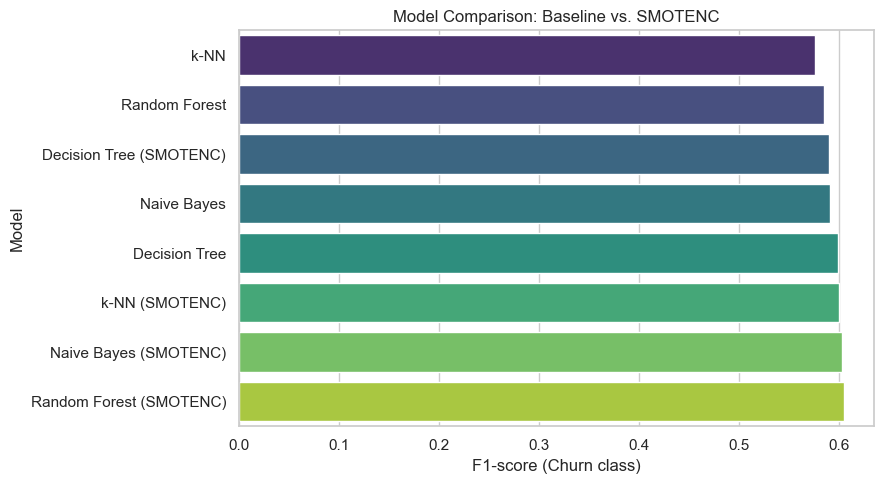

In [8]:
plt.figure(figsize=(9, 5))
order = full_results.sort_values("F1-score", ascending=True).index
sns.barplot(
    x=full_results.loc[order, "F1-score"],
    y=order,
    hue=order,
    palette="viridis",
    legend=False,
)
plt.xlabel("F1-score (Churn class)")
plt.title("Model Comparison: Baseline vs. SMOTENC")
plt.tight_layout()
plt.savefig("../reports/figures_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.2 ROC Curves

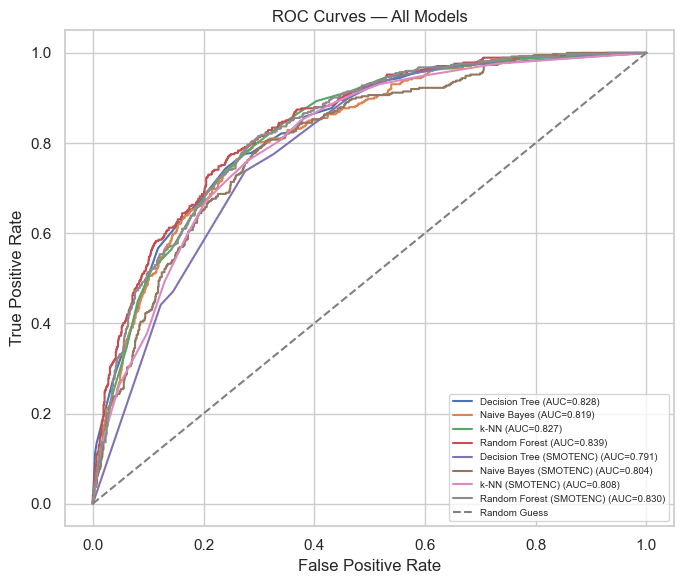

In [9]:
plt.figure(figsize=(7, 6))
for name, model in best_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig("../reports/figures_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.3 Precision–Recall Curves


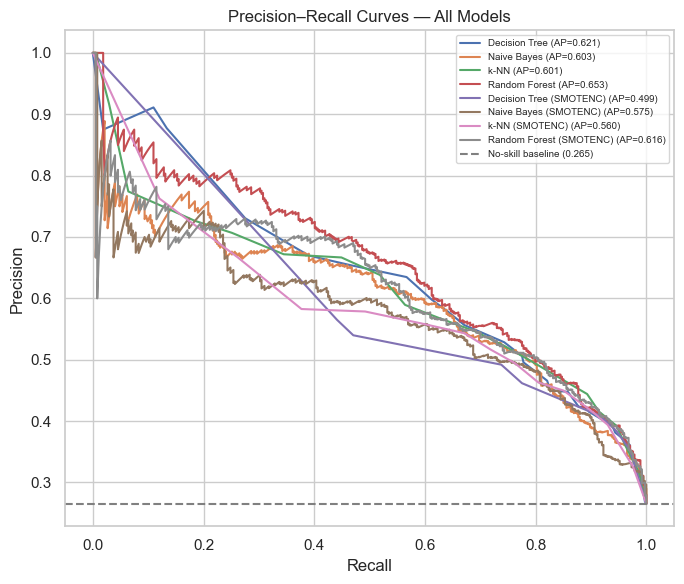

In [10]:
plt.figure(figsize=(7, 6))
positive_rate = y_test.mean()
for name, model in best_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.axhline(
    positive_rate, linestyle="--", color="gray",
    label=f"No-skill baseline ({positive_rate:.3f})"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves — All Models")
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig("../reports/figures_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.4 Confusion Matrices (Best Baseline vs. Best SMOTENC Model)


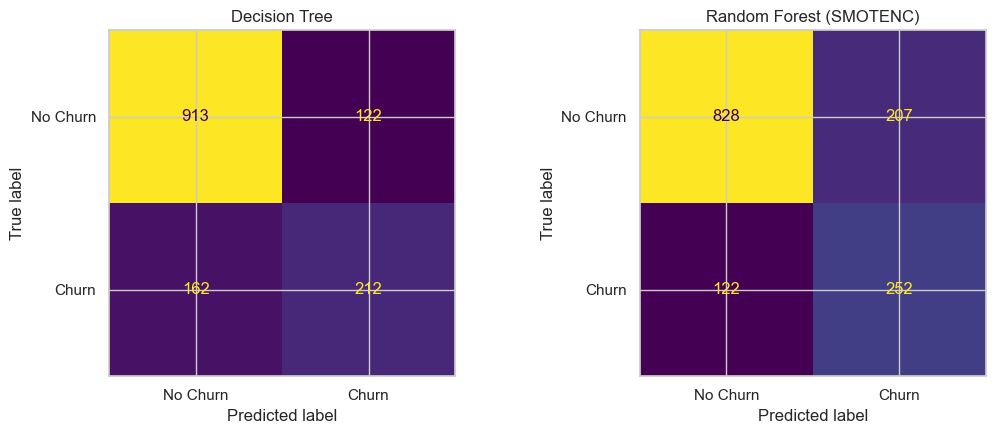

Best baseline model (by F1): Decision Tree
Best SMOTENC-trained model (by F1): Random Forest (SMOTENC)


In [11]:
best_baseline_name = results_df["F1-score"].idxmax()
best_smote_name = smote_results_df["F1-score"].idxmax()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, name in zip(axes, [best_baseline_name, best_smote_name]):
    model = best_models[name]
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(
        cm, display_labels=["No Churn", "Churn"]
    ).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.savefig(
    "../reports/figures_confusion_matrices.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print("Best baseline model (by F1):", best_baseline_name)
print("Best SMOTENC-trained model (by F1):", best_smote_name)


### 6.5 Feature Importance (Baseline Random Forest)


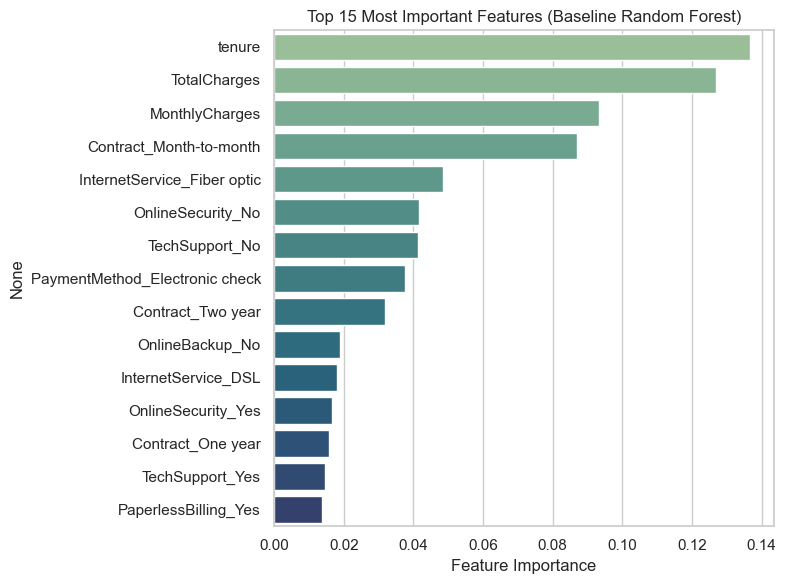

In [12]:
rf_pipeline = best_models["Random Forest"]
rf_model = rf_pipeline.named_steps["classifier"]
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = pd.Series(rf_model.feature_importances_, index=feature_names)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(
    x=top15.values,
    y=top15.index,
    hue=top15.index,
    palette="crest",
    legend=False,
)
plt.xlabel("Feature Importance")
plt.title("Top 15 Most Important Features (Baseline Random Forest)")
plt.tight_layout()
plt.savefig(
    "../reports/figures_feature_importance.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()


## 7. Summary

The complete baseline and SMOTENC comparison is saved to
`../results/model_results.csv`. Report figures are saved to `../reports/`.
Run both notebooks from top to bottom before compiling the report so that its
tables and discussion can be updated with the new results.


In [13]:
print("Files written:")
print(" - ../results/model_results.csv")
print(" - ../reports/figures_f1_comparison.png")
print(" - ../reports/figures_roc_curves.png")
print(" - ../reports/figures_pr_curves.png")
print(" - ../reports/figures_confusion_matrices.png")
print(" - ../reports/figures_feature_importance.png")


Files written:
 - ../results/model_results.csv
 - ../reports/figures_f1_comparison.png
 - ../reports/figures_roc_curves.png
 - ../reports/figures_pr_curves.png
 - ../reports/figures_confusion_matrices.png
 - ../reports/figures_feature_importance.png
